In [8]:
import time
start_time=time.time()

In [9]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult
import math

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

In [10]:
from pipeline_config import MAPS_DIR

In [23]:
data_all = [
    'KPNO-M42-H-bin0',
    'KPNO-M42-N-bin0',
    'KPNO-M42-O-bin0',
    'KPNO-M42-S-bin0',
#    'MUSE-M42-Ar-bin0',
]


# Custom labels dictionary
labels_dict = {
    'KPNO-M42-H-bin0': r'H$\alpha$',
    'KPNO-M42-N-bin0': r'[N II] $\lambda$6583',
    'KPNO-M42-O-bin0': r'[O III] $\lambda$5007',
    'KPNO-M42-S-bin0': r'[S II] $\lambda$6731',
 #   'MUSE-M42-Ar-bin0': r'[Ar III] $\lambda$7136',

}

In [24]:
# Parameters
name = "KPNO-M42-H-bin0"
fits_path = "fits_ready/KPNO-M42-H-bin0.fits"
# Loading obs
hdul = fits.open(fits_path)
hdr = hdul[0].header
#print(hdul.info())
#print(hdr)
sb   = hdul['MOM0'].data.astype(float)
vv   = hdul['MOM1'].data.astype(float)
mask = hdul['MASK'].data.astype(bool)


In [25]:
mask

array([[False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       ...,
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False]])

In [26]:
processed_data = {}
raw_data = {}

for name in data_all:
    fits_path = MAPS_DIR / f"{name}.fits"

    with fits.open(fits_path) as hdul:
        sb = hdul['MOM0'].data.astype(float)
        vv = hdul['MOM1'].data.astype(float)
        mask = hdul['MASK'].data.astype(bool)

    sb = np.where(mask, sb, np.nan)     
    vv = np.where(mask, vv, np.nan)    

    # Apply mask: invalid pixels -> NaN
    #sb[~mask] = np.nan
    #vv[~mask] = np.nan

    # If you still want to treat zero surface brightness as invalid
    #vv[sb == 0] = np.nan

    raw_data[name] = {
        "sb": sb,
        "vv": vv,
        "mask": mask
    }

    # Create DataFrames
    sb_df = (
        pd.DataFrame(sb)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'SB'})
    )

    vv_df = (
        pd.DataFrame(vv)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'VV'})
    )

    # Merge into one DataFrame
    df = vv_df.copy()
    df['SB'] = sb_df['SB']

    processed_data[name] = df

In [27]:
processed_data[data_all[1]].describe()

,X,Y,VV,SB
count,179862.000000,179862.000000,179862.000000,179862.000000
mean,256.348968,176.607332,20.530379,0.193528
std,148.096482,101.406440,2.779798,0.122496
min,0.000000,1.000000,9.205535,0.014281
25%,129.000000,89.000000,18.619456,0.113588
50%,256.000000,177.000000,20.300196,0.166574
75%,385.000000,264.000000,21.973510,0.235799
max,512.000000,352.000000,31.288391,1.000000


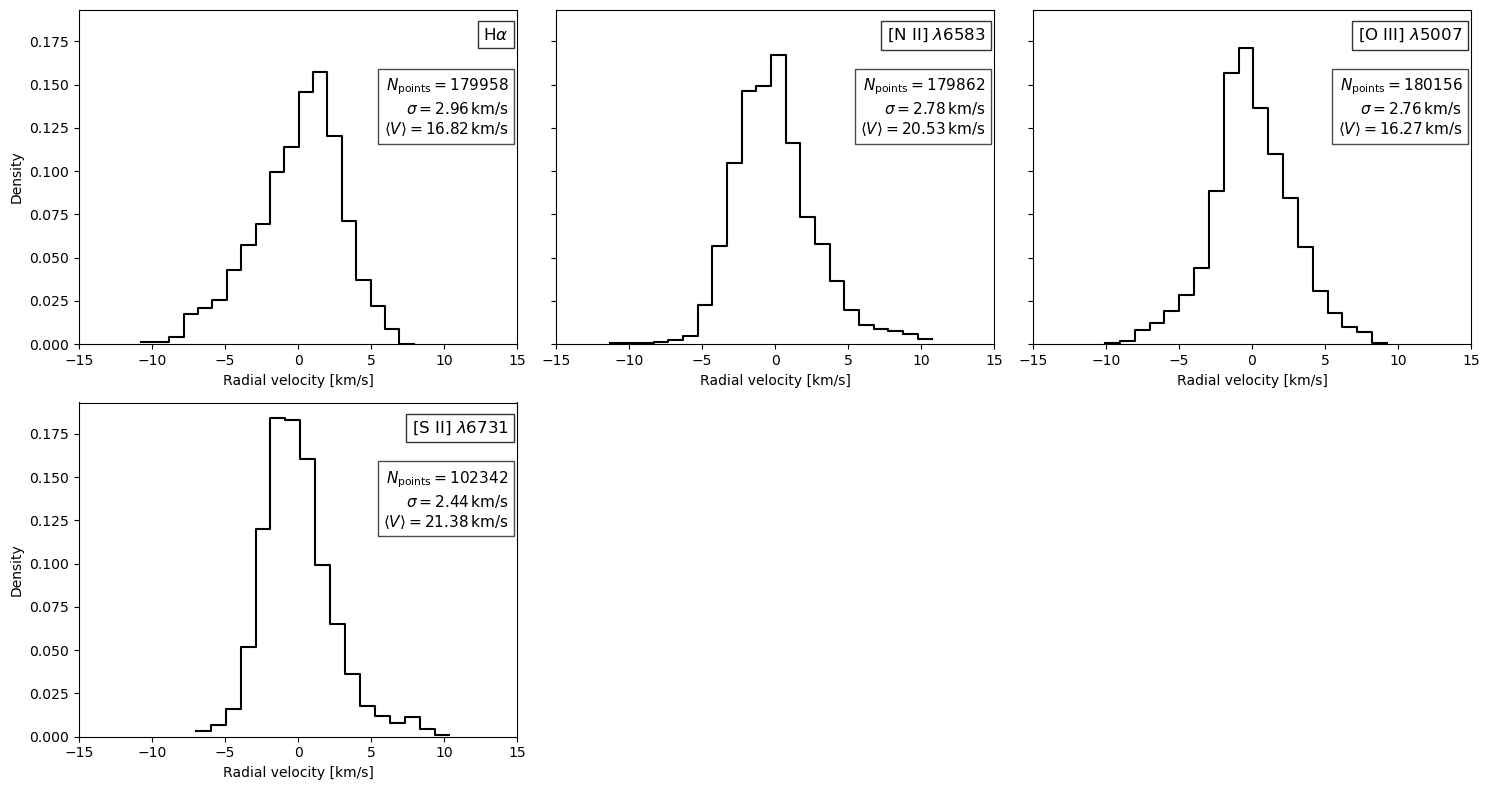

In [28]:
# Layout calculation
n_plots = len(data_all)
n_cols = 3  # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
        
    )

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$\n$\\langle V \\rangle = {df['VV'].mean():.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.80, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")
  #  print(df['VV'].mean())
  #  print(var_rv)
  #  print(df['VV'].std())

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
#plt.savefig("Imgs/pdfs_all.pdf", bbox_inches='tight')
plt.show()

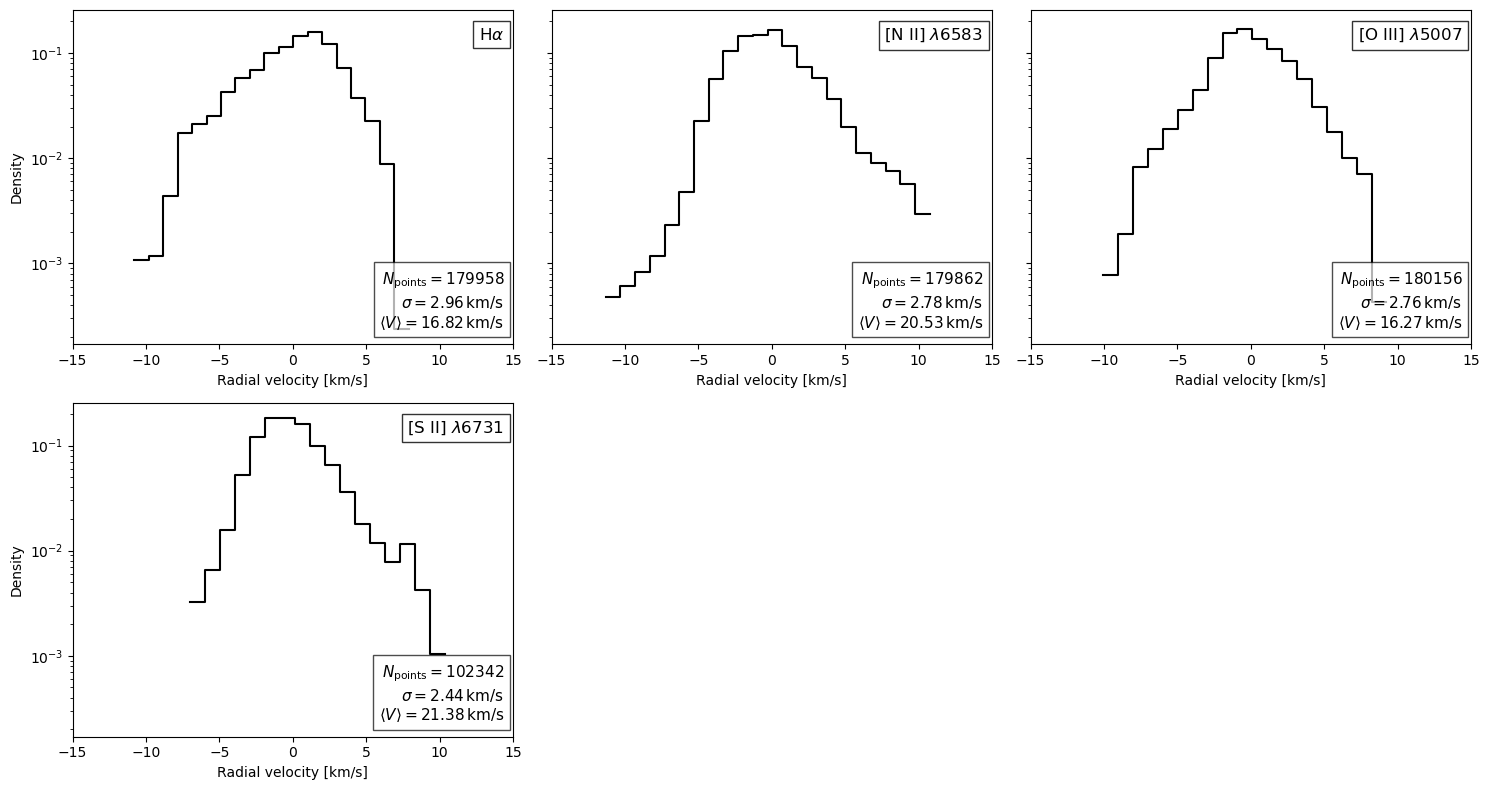

In [29]:
# Layout calculation
n_plots = len(data_all)
n_cols = 3  # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
        
    )
    ax.set_yscale("log")

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$\n$\\langle V \\rangle = {df['VV'].mean():.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.22, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")
  #  print(df['VV'].mean())
  #  print(var_rv)
  #  print(df['VV'].std())

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
#plt.savefig("Imgs/pdfs_all.pdf", bbox_inches='tight')
plt.show()

C:\Users\javas\AppData\Local\Temp\ipykernel_2524\463220413.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar


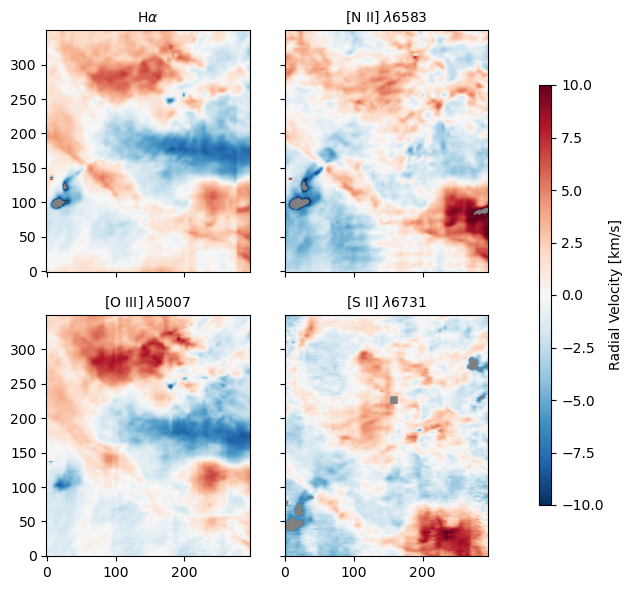

In [30]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

# Loop through datasets
im = None
for ax, name in zip(axes, data_all):
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])

    im = ax.imshow(vv, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
    ax.set_title(labels_dict.get(name, name), fontsize=10)
    
    # Set black background for NaNs
    im.cmap.set_bad(color='gray')
#    ax.invert_yaxis()


# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar in a manually defined axis (position = [left, bottom, width, height])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # adjust as needed
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar
plt.savefig("Imgs/velocity_maps_shared_cbar_fixed.pdf", bbox_inches='tight')
plt.show()